**Objetivo:** Implementar un detector de máximo enfoque sobre un video aplicando técnicas de análisis espectral similar al que utilizan las cámaras digitales modernas. El video a procesar será: “focus_video.mov”.
1. Se debe implementar un algoritmo que dada una imagen, o región, calcule la métrica propuesta en el paper "Image Sharpness Measure for Blurred Images in Frequency Domain“ y realizar tres experimentos:
    1. Medición sobre todo el frame.
    2. Medición sobre una ROI ubicada en el centro del frame. Area de la ROI = 5 o 10% del area total del frame.
    - Opcional:
        - Medición sobre una matriz de enfoque compuesta por un arreglo de NxM elementos rectangulares equiespaciados. N y M son valores arbitrarios, probar con varios valores 3x3, 7x5, etc ... (al menos 3)
    - Para cada experimento se debe presentar :
        - Una curva o varias curvas que muestren la evolución de la métrica frame a frame donde se vea claramente cuando el algoritmo detecto el punto de máximo enfoque.  

2. Cambiar la métrica de enfoque eligiendo uno de los algoritmos explicados en el apéndice de: Analysis of focus measure operators in shapefrom focus.

El algoritmo de detección a implementar debe detectar y devolver los puntos de máximo enfoque de manera
automática.

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def kanjar_algorithm(image):
    m, n = image.shape
    # Genero la transformacion de Fourier de la imagen
    image_fourier = np.fft.fft2(image)
    # Shifteo el origen de la TF al centro
    image_fourier = np.fft.fftshift(image_fourier)
    # Computo el valor absoluto de la TF centrada
    af = np.abs(image_fourier)
    # Calculo el maximo de AF
    max_af = np.max(af)
    # Calculo la cantidad de pixeles con valor > thres
    thres = max_af / 1000
    th = 0
    for row in af:
        for pixel in row:
            if pixel > thres:
                th += 1
    # Computo la metrica
    iqm = th / (m * n)
    return iqm

In [86]:
video_path = 'focus_video.mov'
captura_video = cv.VideoCapture(video_path)

metric = []
metric_center = []
metric_matriz_enfoque = []
if not captura_video.isOpened():
    raise Exception("Error al abrir el archivo de video")
else:
    i = 0
    while True:
        ret, frame = captura_video.read()
        if not ret:
            break
        frame = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)
        metric.append(kanjar_algorithm(frame))

        # Metrica con centro de la imagen
        m, n = frame.shape
        percent = 0.05
        ymin, ymax = int(m/2 - percent/2 * m), int(m/2 + percent/2 * m)
        xmin, xmax = int(n/2 - percent/2 * n), int(n/2 + percent/2 * n)
        frame_center = frame[ymin:ymax, xmin:xmax]
        metric_center.append(kanjar_algorithm(frame_center))

        # Metrica con matriz de enfoque
        center_x, center_y = int(m/2), int(n/2)
        focus_m, focus_n = (5,3) # tamaño de las zonas de enfoque
        m_matrix, n_matrix = (7,5) # cantidad de zonas de enfoque
        rows = [
            (int((center_x + 2*(i - m_matrix)*focus_m) - (focus_m - 1)/2), 
             int((center_x + 2*(i - m_matrix)*focus_m) + (focus_m - 1)/2))
            for i in range(m_matrix*2 + 1)
        ]
        cols = [
            (int((center_y + 2*(i - n_matrix)*focus_n) - (focus_n - 1)/2), 
             int((center_y + 2*(i - n_matrix)*focus_n) + (focus_n - 1)/2))
            for i in range(n_matrix*2 + 1)
        ]
        focus_matrix = np.concatenate([frame[r1:r2,c1:c2] for r1,r2 in rows for c1,c2 in cols])
        metric_matriz_enfoque.append(kanjar_algorithm(focus_matrix))


In [91]:
def view_video(captura_video, focus_zones):
    '''
    '''
    # Va al frame 0
    captura_video.set(cv.CAP_PROP_POS_FRAMES, 0)
    if not captura_video.isOpened():
        print("Error al abrir el archivo de video")
    else:
        # Obtén la tasa de cuadros (frame rate) del video
        fps = int(captura_video.get(cv.CAP_PROP_FPS)) * 0.25
        #fps = 35
        delay = int(600 / fps)
        
        banner_height = 40 + 30 * (len(focus_zones.keys()) - 1) # How tall you want the banner to be

        frame_count = 0
        while True:
            ret, frame = captura_video.read()
            frame_count += 1
            if not ret:
                break

            h, w, channels = frame.shape
            composite_frame = np.zeros((h+banner_height, w, channels), dtype=np.uint8)
            composite_frame[0:h, 0:w] = frame

            percent = 0.05
            percent = 0.10
            cv.rectangle(composite_frame, (int(w/2 - w*percent/2), int(h/2 - h*percent/2)), (int(w/2 + w*percent/2), int(h/2 + h*percent/2)), (0, 255, 0), 3)
            
            metric_counter = 0
            for metric in focus_zones.keys():
                in_focus = False
                for focus_zone in focus_zones[metric]:
                    if frame_count >= focus_zone[0] and frame_count <= focus_zone[1]:
                        in_focus = True
                banner_text = f"{metric}: Enfocado" if in_focus else f"{metric}: No enfocado"

                text_position = (20, h + 30 * (1 + metric_counter)) # X, Y coordinates for the text start
                metric_counter += 1
                cv.putText(composite_frame, banner_text, text_position, cv.FONT_HERSHEY_SIMPLEX, 
                            0.8, (255, 255, 255), 2, cv.LINE_AA)
            
            # Mostrar el frame combinado
            cv.imshow('Video Original y Blur Gaussiano', composite_frame)
            
            # Salir del loop si se presiona la tecla 'q'
            if cv.waitKey(delay) & 0xFF == ord('q'):
                break

    # Cierra todas las ventanas
    cv.destroyAllWindows()

In [87]:
view_video(captura_video, {1: [(0,50), (100,150)], 2: [(30,70)]})

In [61]:
def get_focus_zones(metric_list, thres, norm=True):
    focus_zones = []
    focused = False
    thres = thres if not norm else thres * np.max(metric_list)
    for frame, point in enumerate(metric_list):
        if point > thres and not focused:
            focused = True
            focus_zones.append(frame)
        if focused and point < thres:
            focused = False
            focus_zones[-1] = (focus_zones[-1],frame)

    return focus_zones

focus_zones_full = get_focus_zones(metric, 0.8, norm=False)
focus_zones_full_norm = get_focus_zones(metric, 0.8, norm=True)

focus_zones_center = get_focus_zones(metric_center, 0.8, norm=False)
focus_zones_center_norm = get_focus_zones(metric_center, 0.8, norm=True)

focus_zones_matrix = get_focus_zones(metric_matriz_enfoque, 0.8, norm=False)
focus_zones_matrix_norm = get_focus_zones(metric_matriz_enfoque, 0.8, norm=True)

In [92]:
view_video(
    captura_video=captura_video,
    focus_zones={
        "Full frame normalizado": focus_zones_full_norm,
        "Centro de  frame normalizado": focus_zones_center_norm,
        "Matriz de enfoque": focus_zones_matrix,
    }
)

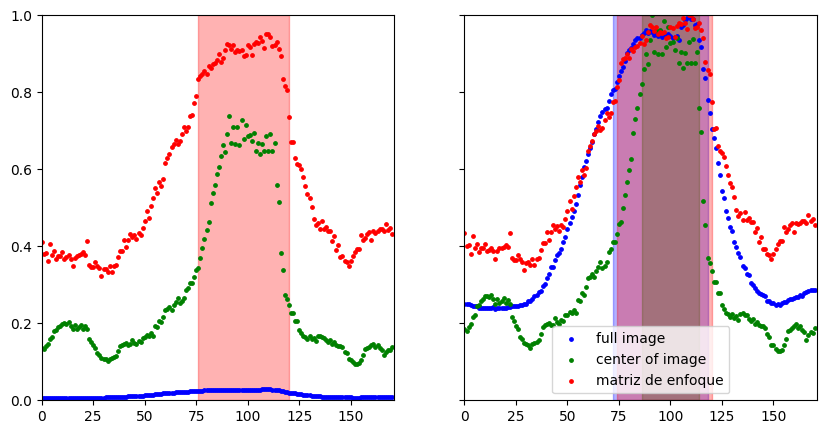

In [72]:
fig, axs = plt.subplots(1,2,figsize=(10,5), sharex=True, sharey=True)

axs[0].scatter(range(len(metric)), metric, label='full image', color='blue', s=6,zorder=2)
axs[0].scatter(range(len(metric_center)), metric_center, label='center of image', color='green', s=6,zorder=2)
axs[0].scatter(range(len(metric_matriz_enfoque)), metric_matriz_enfoque, label='matriz de enfoque', color='red', s=6,zorder=2)
# axs[0].fill_between(focus_zones_full[0],1,alpha=0.3,color='blue',zorder=1)
# axs[0].fill_between(focus_zones_center[0],1,alpha=0.3,color='green',zorder=1)
axs[0].fill_between(focus_zones_matrix[0],1,alpha=0.3,color='red',zorder=1)

axs[1].scatter(range(len(metric)), metric/np.max(metric), label='full image', color='blue', s=6,zorder=2)
axs[1].scatter(range(len(metric_center)), metric_center/np.max(metric_center), label='center of image', color='green', s=6,zorder=2)
axs[1].scatter(range(len(metric_matriz_enfoque)), metric_matriz_enfoque/np.max(metric_matriz_enfoque), label='matriz de enfoque', color='red', s=6,zorder=2)
axs[1].fill_between(focus_zones_full_norm[0],1,alpha=0.3,color='blue',zorder=1)
axs[1].fill_between(focus_zones_center_norm[0],1,alpha=0.3,color='green',zorder=1)
axs[1].fill_between(focus_zones_matrix_norm[0],1,alpha=0.3,color='red',zorder=1)
axs[1].legend()

for ax in axs:
    [ax.fill_between(focus_zone,1,alpha=0.3,color='blue',zorder=1) for focus_zone in focus_zones_full]
    [ax.fill_between(focus_zone,1,alpha=0.3,color='blue',zorder=1) for focus_zone in focus_zones_full]
    ax.set_ylim(0,1)
    ax.set_xlim(0,len(metric))